In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tinyshift.association_mining import TransactionAnalyzer
rng = np.random.default_rng(42)
from typing import List
import kagglehub
from kagglehub import KaggleDatasetAdapter
from doubleml import DoubleMLData, DoubleMLPLR
from lightgbm import LGBMRegressor

/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_groceries = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "irfanasrullah/groceries", "groceries - groceries.csv")
df_groceries = df_groceries[df_groceries.columns[1:]].fillna("")
groceries = df_groceries.to_numpy()
groceries = [arr[np.where(arr != "")] for arr in groceries]

In [16]:
from typing import List, Dict, Optional, Union
import pandas as pd
import numpy as np
from scipy import sparse
from doubleml import DoubleMLData, DoubleMLPLR
from lightgbm import LGBMRegressor
from mlforecast import MLForecast


class ForecastPrice:
    """
    Pipeline de previsão de demanda com ajuste causal de elasticidade cruzada e canibalização.
    """

    def __init__(self, mlforecast_model: Optional[MLForecast] = None):
        self.mask_: Optional[pd.DataFrame] = None
        self.sparse_mask_: Optional[sparse.csr_matrix] = None
        self.competitors_dict_: Dict[str, List[str]] = {}
        self.skus_: Optional[List[str]] = None
        self.id_col_: Optional[str] = None
        self.time_col_: Optional[str] = None
        self.target_col_: Optional[str] = None
        
        # Dicionário de modelos DML por SKU alvo
        self.dml_models_: Dict[str, DoubleMLPLR] = {}
        
        # Dicionário de elasticidades cruzadas médias -> {sku_target: {sku_competitor: elasticity}}
        self.cross_elasticities_: Dict[str, Dict[str, float]] = {}
        
        # Modelo base de séries temporais (Nixtla MLForecast)
        self.mlforecast = mlforecast_model

    def fit_mask_(self, transactions: List[List[str]]):
        """
        Calcula e armazena a matriz de concorrência como DataFrame esparso.
        """
        ta = TransactionAnalyzer().fit(transactions)
        self.skus_ = list(ta.columns_)
        
        lift = ta.correlation_matrix(self.skus_, self.skus_, metric="lift")
        hypergeom_p = ta.correlation_matrix(self.skus_, self.skus_, metric="hypergeom")
        
        bool_mask = (hypergeom_p < 0.05) & (lift > 1.2)
        mask_matrix = sparse.csr_matrix(bool_mask.to_numpy(dtype=bool))
        self.sparse_mask_ = mask_matrix
        self.mask_ = pd.DataFrame.sparse.from_spmatrix(
            mask_matrix,
            index=self.skus_,
            columns=self.skus_
        )

        self.competitors_dict_ = {}
        for sku in self.skus_:
            competing = self.mask_.loc[sku][self.mask_.loc[sku]].index.tolist()
            if competing:
                self.competitors_dict_[sku] = competing

        return self

    def get_competitors(self, sku_target: str) -> List[str]:
        """
        Retorna a lista de SKUs concorrentes para um SKU específico.
        """
        return self.competitors_dict_.get(sku_target, [])

    def fit_cross_elasticity_(
        self,
        df_panel: pd.DataFrame,
        id_col: str,
        target_col: str,
        sku_target: str,
        control_cols: List[str]
    ):
        """
        Ajusta um DoubleMLPLR log-log para estimar a elasticidade cruzada do SKU alvo.
        """
        competitors = self.get_competitors(sku_target)
        if not competitors:
            print(f"Nenhum concorrente significativo encontrado para {sku_target}.")
            return

        df_sku = df_panel[df_panel[id_col] == sku_target].copy()
        available_competitors = [
            comp for comp in competitors if f"price_{comp}" in df_sku.columns
        ]
        if not available_competitors:
            return

        outcome_col = "__log_target"
        treatment_cols = [f"__log_price_{comp}" for comp in available_competitors]
        raw_treatment_cols = [f"price_{comp}" for comp in available_competitors]
        required_cols = [target_col] + raw_treatment_cols + control_cols
        df_dml = df_sku[required_cols].dropna().reset_index(drop=True)
        if df_dml.empty:
            return

        df_dml[outcome_col] = np.log1p(df_dml[target_col].clip(lower=0))
        for raw_col, treatment_col in zip(raw_treatment_cols, treatment_cols):
            df_dml[treatment_col] = np.log(df_dml[raw_col].clip(lower=1e-8))

        dml_data = DoubleMLData(
            df_dml,
            y_col=outcome_col,
            d_cols=treatment_cols,
            x_cols=control_cols,
        )
        dml = DoubleMLPLR(
            dml_data,
            ml_l=LGBMRegressor(
                n_estimators=100,
                max_depth=3,
                verbose=-1,
                random_state=42,
            ),
            ml_m=LGBMRegressor(
                n_estimators=100,
                max_depth=3,
                verbose=-1,
                random_state=42,
            ),
            n_folds=3,
        )
        dml.fit()

        self.dml_models_[sku_target] = dml
        self.cross_elasticities_[sku_target] = {
            comp: float(dml.summary.loc[f"__log_price_{comp}", "coef"])
            for comp in available_competitors
        }

    def fit_mlforecast_(
        self,
        df_panel: pd.DataFrame,
        id_col: str,
        time_col: str,
        target_col: str,
        static_features: Optional[List[str]] = None,
    ):
        """
        Treina o modelo de séries temporais da Nixtla (MLForecast).
        """
        if self.mlforecast is None:
            raise ValueError("Forneça uma instância válida de MLForecast no __init__.")

        static_features = list(static_features or [])
        forecast_cols = list(dict.fromkeys([id_col, time_col, target_col] + static_features))
        forecast_panel = df_panel[forecast_cols].copy()
        self.mlforecast.fit(
            forecast_panel,
            id_col=id_col,
            time_col=time_col,
            target_col=target_col,
            static_features=static_features,
        )

    def fit(
        self,
        transactions: List[List[str]],
        df_panel: pd.DataFrame,
        control_cols: List[str],
        id_col: str,
        time_col: str,
        target_col: str,
        static_features: Optional[List[str]] = None,
    ):
        """
        Executa o pipeline completo: Máscara -> Causal DML -> MLForecast.
        """
        self.id_col_ = id_col
        self.time_col_ = time_col
        self.target_col_ = target_col

        # 1. Gera matriz de concorrência
        self.fit_mask_(transactions)

        # 2. Treina elasticidades cruzadas para todos os SKUs que possuem concorrentes
        for sku in self.skus_:
            if sku in self.competitors_dict_:
                self.fit_cross_elasticity_(
                    df_panel=df_panel,
                    id_col=id_col,
                    target_col=target_col,
                    sku_target=sku,
                    control_cols=control_cols,
                )

        # 3. Treina o forecast base de séries temporais
        self.fit_mlforecast_(
            df_panel=df_panel,
            id_col=id_col,
            time_col=time_col,
            target_col=target_col,
            static_features=static_features,
        )

        return self

    def predict(self, h: int, delta_prices: Optional[Dict[str, Dict[str, float]]] = None) -> pd.DataFrame:
        """
        Faz a previsão de demanda futura e aplica o ajuste contrafactual.
        
        delta_prices: Dicionário no formato:
            {'SKU_B': {'SKU_A': 0.15}} -> Representa aumento de 15% no preço do SKU_A afetando o SKU_B.
        """
        # Previsão base não-restrita via Nixtla
        base_forecast = self.mlforecast.predict(h=h)
        adjusted_forecast = base_forecast.copy()

        if delta_prices is None:
            return adjusted_forecast

        # Aplica a correção de canibalização/substituição por SKU
        for target_sku, comp_deltas in delta_prices.items():
            if target_sku not in self.cross_elasticities_:
                continue

            multiplier = 0.0
            for comp_sku, delta_p in comp_deltas.items():
                elasticity = self.cross_elasticities_[target_sku].get(comp_sku, 0.0)
                multiplier += elasticity * delta_p

            # Aplica o ajuste proporcional nas colunas de modelo do MLForecast
            mask_sku = adjusted_forecast[self.id_col_] == target_sku
            model_cols = [
                c for c in adjusted_forecast.columns
                if c not in [self.id_col_, self.time_col_]
            ]
            
            for col in model_cols:
                adjusted_forecast.loc[mask_sku, col] = (
                    adjusted_forecast.loc[mask_sku, col] * (1 + multiplier)
                )

        return adjusted_forecast

In [5]:
fp = ForecastPrice()

/tmp/ipykernel_159654/2980273330.py:46: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  self.mask_ = pd.DataFrame.sparse.from_spmatrix(
/tmp/ipykernel_159654/2980273330.py:54: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  competing = self.mask_.loc[sku][self.mask_.loc[sku]].index.tolist()
/tmp/ipykernel_159654/2980273330.py:54: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  competing = self.mask_.loc[sku][self.mask_.loc[sku]].index.tolist()
/tmp/ipykernel_159654/2980273330.py:54: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for

Arquivo: online_retail_II.csv
Linhas válidas: 25,341 | SKUs: 12 | Transações: 4,254
Treino: 2009-12-01 a 2011-07-15 | Horizonte: 28 dias
Pares concorrentes estimados: 25


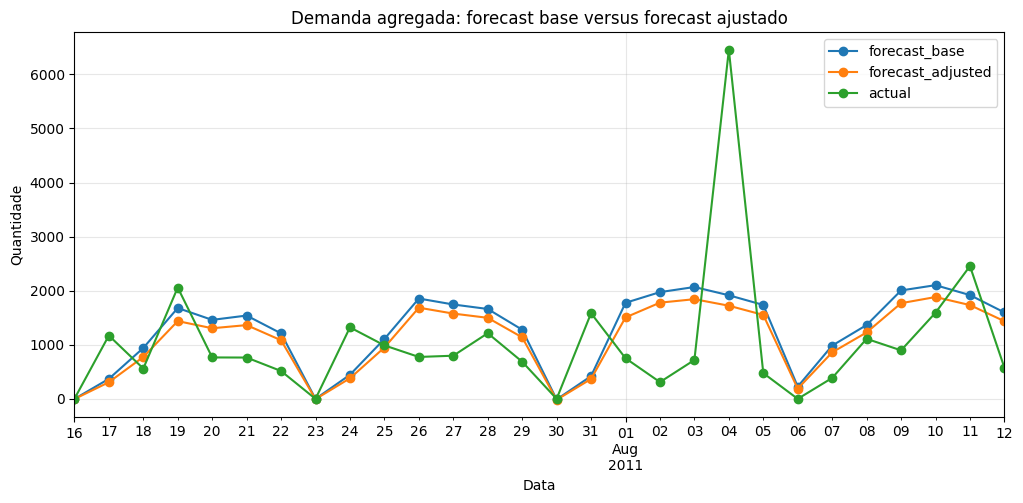

In [18]:
from pathlib import Path

from mlforecast import MLForecast

# Online Retail II: mais de 1 milhão de linhas com invoice, SKU, data, quantidade e preço.
dataset_dir = Path(kagglehub.dataset_download("mashlyn/online-retail-ii-uci"))
retail_files = list(dataset_dir.rglob("*.csv"))
if not retail_files:
    raise FileNotFoundError(f"Nenhum CSV encontrado em {dataset_dir}")

retail_path = retail_files[0]
raw_retail = pd.read_csv(retail_path, encoding="latin1")
price_col = "Price" if "Price" in raw_retail.columns else "UnitPrice"
retail = raw_retail[["Invoice", "StockCode", "InvoiceDate", "Quantity", price_col]].copy()
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"], errors="coerce")
retail["StockCode"] = retail["StockCode"].astype(str)
retail = retail.loc[
    retail["InvoiceDate"].notna()
    & retail["Invoice"].notna()
    & (retail["Quantity"] > 0)
    & (retail[price_col] > 0)
].copy()
retail["ds"] = retail["InvoiceDate"].dt.floor("D")

# Mantém os SKUs com maior volumetria para deixar a demonstração representativa e executável.
top_skus = (
    retail.groupby("StockCode")["Quantity"]
    .sum()
    .nlargest(12)
    .index
    .tolist()
)
retail = retail[retail["StockCode"].isin(top_skus)].copy()

# Transações para o TransactionAnalyzer, restritas aos SKUs selecionados.
transactions = (
    retail.groupby("Invoice")["StockCode"]
    .agg(lambda values: sorted(set(values)))
    .loc[lambda series: series.map(len) >= 2]
    .tolist()
)

# Painel diário completo de demanda e preço por SKU.
dates = pd.date_range(retail["ds"].min(), retail["ds"].max(), freq="D")
panel = (
    pd.MultiIndex.from_product([dates, top_skus], names=["ds", "sku"])
    .to_frame(index=False)
)

daily_demand = (
    retail.groupby(["ds", "StockCode"])["Quantity"]
    .sum()
    .rename("y")
    .reset_index()
    .rename(columns={"StockCode": "sku"})
)
daily_price = (
    retail.groupby(["ds", "StockCode"])[price_col]
    .mean()
    .rename("price")
    .reset_index()
    .rename(columns={"StockCode": "sku"})
)
panel = panel.merge(daily_demand, on=["ds", "sku"], how="left")
panel = panel.merge(daily_price, on=["ds", "sku"], how="left")
panel["y"] = panel["y"].fillna(0.0)
panel["price"] = panel.groupby("sku")["price"].transform(
    lambda values: values.ffill().bfill()
)
panel["dow"] = panel["ds"].dt.dayofweek
panel["is_weekend"] = (panel["dow"] >= 5).astype(int)

# Preços dos demais SKUs como colunas de tratamento para o DoubleML.
price_wide = panel.pivot(index="ds", columns="sku", values="price").add_prefix("price_")
panel = panel.drop(columns="price").merge(price_wide, on="ds", how="left")

cutoff = panel["ds"].quantile(0.80)
train_panel = panel[panel["ds"] <= cutoff].copy()
test_panel = panel[panel["ds"] > cutoff].copy()
train_dates = set(train_panel["ds"])
train_transactions = (
    retail[retail["ds"].isin(train_dates)]
    .groupby("Invoice")["StockCode"]
    .agg(lambda values: sorted(set(values)))
    .loc[lambda series: series.map(len) >= 2]
    .tolist()
)

mlf = MLForecast(
    models={"lgbm": LGBMRegressor(n_estimators=120, max_depth=6, verbose=-1, random_state=42)},
    lags=[1, 7, 14, 28],
    date_features=["dayofweek", "month"],
    freq="D",
)
fp = ForecastPrice(mlforecast_model=mlf)
fp.fit(
    transactions=train_transactions,
    df_panel=train_panel,
    control_cols=["dow", "is_weekend"],
    id_col="sku",
    time_col="ds",
    target_col="y",
    static_features=[],
)

h = min(28, test_panel["ds"].nunique())
forecast_base = fp.predict(h=h)

# Cenário: aumento de 10% nos preços dos concorrentes identificados pela máscara.
price_scenario = {
    target: {competitor: 0.10 for competitor in competitors}
    for target, competitors in fp.competitors_dict_.items()
    if target in top_skus
}
forecast_adjusted = fp.predict(h=h, delta_prices=price_scenario)

prediction_cols = ["sku", "ds", "lgbm"]
comparison = forecast_base[prediction_cols].rename(columns={"lgbm": "forecast_base"})
comparison = comparison.merge(
    forecast_adjusted[prediction_cols].rename(columns={"lgbm": "forecast_adjusted"}),
    on=["sku", "ds"],
)
actual = (
    test_panel.groupby(["sku", "ds"])["y"]
    .sum()
    .reset_index(name="actual")
)
comparison = comparison.merge(actual, on=["sku", "ds"], how="left")
summary = comparison[["forecast_base", "forecast_adjusted", "actual"]].sum().to_frame().T
summary["delta_adjustment_pct"] = 100 * (
    summary["forecast_adjusted"] / summary["forecast_base"] - 1
)

print(f"Arquivo: {retail_path.name}")
print(f"Linhas válidas: {len(retail):,} | SKUs: {len(top_skus)} | Transações: {len(train_transactions):,}")
print(f"Treino: {train_panel['ds'].min().date()} a {train_panel['ds'].max().date()} | Horizonte: {h} dias")
print(f"Pares concorrentes estimados: {sum(map(len, fp.competitors_dict_.values()))}")
summary

comparison_by_day = comparison.groupby("ds")[["forecast_base", "forecast_adjusted", "actual"]].sum()
ax = comparison_by_day.plot(figsize=(12, 5), marker="o")
ax.set_title("Demanda agregada: forecast base versus forecast ajustado")
ax.set_xlabel("Data")
ax.set_ylabel("Quantidade")
ax.grid(alpha=0.3)
plt.show()

In [19]:
print("Resumo agregado do demand_class:")
display(summary)
summary

Resumo agregado do demand_class:


,forecast_base,forecast_adjusted,actual,delta_adjustment_pct
0,35371.267768,31345.307452,28932.0,-11.382007


,forecast_base,forecast_adjusted,actual,delta_adjustment_pct
0,35371.267768,31345.307452,28932.0,-11.382007
